# Importación de librerías

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# Carga de archivos (.txt) y etiquetado

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

# Configura las rutas.
bueno_dir = '/content/drive/MyDrive/Colab Notebooks/BUENO'
malo_dir = '/content/drive/MyDrive/Colab Notebooks/MALO'

X_features = []
y_labels = []

def cargar_datos_tiempo_real(ruta_carpeta, etiqueta):
    conteo_archivos = 0
    conteo_filas = 0
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".txt"):
            ruta_completa = os.path.join(ruta_carpeta, archivo)
            try:
                # Carga archivos de 14 columnas (limpiados previamente).
                df = pd.read_csv(ruta_completa, sep=' ', decimal=',', header=0)
                df = df.apply(pd.to_numeric, errors='coerce').dropna()

                # Filtra por fase: Solo usa las filas donde Aire/Muestra es 1 (Muestra).
                # En el archivo procesado por Limpiador.py, la fase está en la última columna (índice 13).
                df_muestra = df[df.iloc[:, 13] == 1]

                # Extrae solo las 13 columnas de sensores de gas (índices 0 al 12).
                for row in df_muestra.values:
                    X_features.append(row[:13])
                    y_labels.append(etiqueta)
                    conteo_filas += 1
                conteo_archivos += 1
            except Exception as e:
                print(f"Error en {archivo}: {e}")

    print(f"Carpeta {os.path.basename(ruta_carpeta)}: {conteo_archivos} archivos, {conteo_filas} filas de muestra.")

# Carga los datos.
n_buenos = cargar_datos_tiempo_real(bueno_dir, 1) # Clase Positiva
n_malos = cargar_datos_tiempo_real(malo_dir, 0)  # Clase Negativa

X = np.array(X_features)
y = np.array(y_labels)

print(f"Finalizado: {n_buenos} archivos BUENOS y {n_malos} archivos MALOS cargados.")
print(f"Forma de la matriz X: {X.shape}")

Carpeta BUENO: 58 archivos, 8550 filas de muestra.
Carpeta MALO: 58 archivos, 8699 filas de muestra.
Finalizado: None archivos BUENOS y None archivos MALOS cargados.
Forma de la matriz X: (17249, 13)


# División del Dataset (Train, Val, Test) y Escalado

In [4]:
# Realiza la primera división: Separa el 15% para el TEST FINAL.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Realiza la segunda división: Del resto (85%), separa un ~18% para obtener un 15% del total para VALIDACIÓN.
# (0.85 * 0.176 \u2248 0.15)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

# Realiza el escalado estándar (Z-score).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Muestras totales: {len(X)}")
print(f"Entrenamiento: {len(X_train_scaled)} (70%)")
print(f"Validación:    {len(X_val_scaled)} (15%)")
print(f"Test Final:    {len(X_test_scaled)} (15%)")

Muestras totales: 17249
Entrenamiento: 12080 (70%)
Validación:    2581 (15%)
Test Final:    2588 (15%)


# Definición y Entrenamiento de la ANN

In [12]:
# Define el modelo.
model = Sequential([
    Dense(16, activation='relu', input_shape=(13,)),
    Dropout(0.2), # Aumenta el dropout para evitar el sobreajuste.
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Configura la parada temprana monitorizando la pérdida de VALIDACIÓN.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entrena el modelo.
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, y_val), # Usa el conjunto de validación explícito.
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


378/378 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6544 - loss: 0.5725 - val_accuracy: 0.7927 - val_loss: 0.3856
Epoch 2/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7851 - loss: 0.3910 - val_accuracy: 0.8256 - val_loss: 0.3280
Epoch 3/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8169 - loss: 0.3451 - val_accuracy: 0.8609 - val_loss: 0.2983
Epoch 4/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8327 - loss: 0.3105 - val_accuracy: 0.8532 - val_loss: 0.2799
Epoch 5/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8431 - loss: 0.2858 - val_accuracy: 0.8640 - val_loss: 0.2638
Epoch 6/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8564 - loss: 0.2691 - val_accuracy: 0.8725 - val_loss: 0.2491
Epoch 7/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8594 - loss: 0.2588 - val_accuracy: 0.8826 - val_loss: 0.2407
Epoch 8/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8617 - loss: 0.2503 - val_accuracy: 0.8822

# Evaluación y Resultados

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9451 - loss: 0.1176

>> PRECISIÓN FINAL EN EL TEST: 94.67%


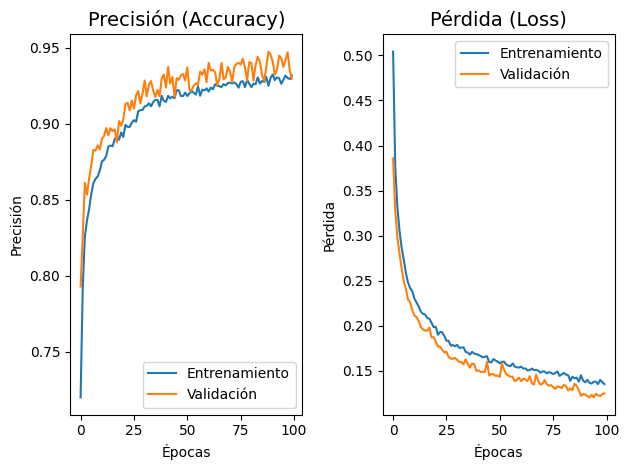

In [13]:
# Evalúa con el conjunto de Test.
loss, acc = model.evaluate(X_test_scaled, y_test)
print(f"\n>> PRECISIÓN FINAL EN EL TEST: {acc*100:.2f}%")

# Genera la gráfica de Precisión (Accuracy).
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión (Accuracy)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Genera la gráfica de Pérdida (Loss).
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


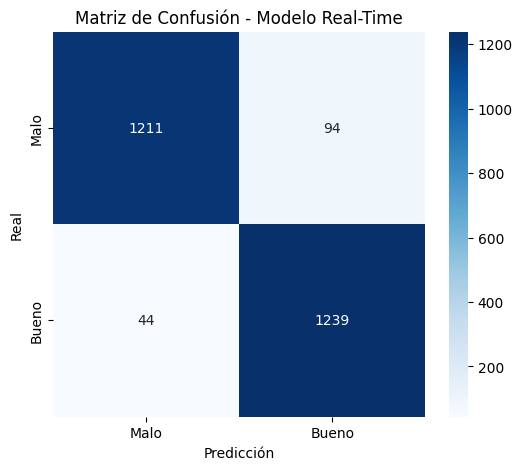

In [14]:
# Realiza predicciones en el conjunto de prueba.
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malo', 'Bueno'], yticklabels=['Malo', 'Bueno'])
plt.title('Matriz de Confusión - Modelo Real-Time')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

# Exportar y guardar el modelo

In [8]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = '/content/modelo_hachis2.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"\nProceso finalizado. Descarga el archivo: {tflite_path}")

Saved artifact at '/tmp/tmpgmomtydf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138674023168528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138673737436048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138673737436624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138673737434512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138673737435664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138673737437200: TensorSpec(shape=(), dtype=tf.resource, name=None)

Proceso finalizado. Descarga el archivo: /content/modelo_hachis2.tflite


In [9]:
print("Medias para Flutter:", list(scaler.mean_))
print("Desviaciones para Flutter:", list(np.sqrt(scaler.var_)))

Medias para Flutter: [np.float64(1185.178642384106), np.float64(31173.700993377483), np.float64(2.8593543046357617), np.float64(2955.144370860927), np.float64(2992.8029801324506), np.float64(326.67383443708553), np.float64(303.9587168874178), np.float64(75.14778890728505), np.float64(5.374706125827988), np.float64(1.2143782367549711), np.float64(433.6990894039735), np.float64(2.230546357615894), np.float64(407197.75531873724)]
Desviaciones para Flutter: [np.float64(354.91739903797037), np.float64(2205.048169233811), np.float64(1.0171559396641696), np.float64(11721.886199803515), np.float64(11342.161040580193), np.float64(150.38703057240855), np.float64(174.05580152643338), np.float64(25.101748795707273), np.float64(0.32747419856237336), np.float64(3.9998558809166105), np.float64(44.17601870143902), np.float64(1.0670768541915994), np.float64(118014.64114357348)]
